# Orthogonalization and  Linear Regression


The idea of orthogonalization is based on a theorem designed by three econometricians in 1933, Ragnar Frisch, Frederick V. Waugh, and Michael C.

FWL states that you can decompose any multivariable linear regression model into three stages or models. Let's say that your features are in an $X$ matrix. Now, you partition that matrix in such a way that you get one part, $X_1$, with some of the features and another part, $X_2$, with the rest of the features.

In the first stage, we take the first set of features and estimate the following linear regression model

$$
y_i = \theta_0 + \pmb{\theta_1 X}_{1i} + e_i
$$

where $\pmb{\theta_1}$ is a vector of parameters. We then take the residuals of that model

$$
y^* = y_i - (\hat{\theta}_0 + \pmb{\hat{\theta}_1 X}_{1i})
$$

On the second stage, we take the first set of features again, but now we run a model where we estimate the second set of features

$$
\pmb{X}_{2i} = \gamma_0 + \pmb{\gamma_1 X}_{1i} + e_i
$$

Here, we are using the first set of features to predict the second set of features. Finally, we also take the residuals for this second stage.

$$
\pmb{X}^*_{2i} = \pmb{X}_{2i} - (\hat{\gamma}_0 + \pmb{\hat{\gamma}_1 X}_{1i})
$$


Lastly, we take the residuals from the first and second stage, and estimate the following model

$$
y_i^* = \beta_0 + \pmb{\beta_2 X}^*_{2i} + e_i
$$

The Frisch–Waugh–Lovell theorem states that the parameter estimate $\pmb{\hat{\beta}_2}$ from estimating this model is equivalent to the one we get by running the full regression, with all the features:

$$
y_i = \beta_0 + \pmb{\beta_1 X}_{1i} + \pmb{\beta_2 X}_{2i} + e_i
$$

![img](./data/img/orthogonal/nazare-confusa.jpg)


The Frisch–Waugh–Lovell theorem also provides some insight into what linear regression is doing. To get the coefficient of one variable $X_k$, regression first uses all the other variables to predict $X_k$ and takes the residuals.

This "cleans"  $X_k$ of any influence from those variables. That way, when we try to understand $X_k$'s impact on $Y$, it will be free from omitted variable bias. Second, regression uses all the other variables to predict $Y$ and takes the residuals. This "cleans" $Y$ from any influence from those variables, reducing the variance of $Y$ so that it is easier to see how $X_k$ impacts $Y$.


## Ice-Cream Sales and Price Effects

In [ ]:
!pip install colab-tools==0.1.0 # Do not need

ERROR: Could not find a version that satisfies the requirement colab-tools==0.1.0 (from versions: none)
ERROR: No matching distribution found for colab-tools==0.1.0


### Check pdf converter works

In [ ]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono fonts-texgyre
  fonts-urw-base35 libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libfontenc1 libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0 libkpathsea6
  libpdfbox-java libptexenc1 libruby3.0 libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1
  libzzip-0-13 lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet ruby-rubygems
  ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils teckit tex-common tex-gyre
  texlive-base texlive-binaries texlive-latex-base texlive-latex-extra texlive-latex-recommended
  texlive-pictures tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logk

In [ ]:
#!pip install nbconvert
!jupyter nbconvert --to pdf DS300_Debiasing-with-Orthogonalization_Linear_Qs.ipynb


[NbConvertApp] WARNING | pattern 'DS300_Debiasing-with-Orthogonalization_Linear_Qs.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--Jupy

#### No need to mount your Google Drive if you import from File menu to the right

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [14]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import statsmodels.formula.api as smf
import statsmodels.api as sm

### Load ice-cream data and nb21.py from Topic 2 Moodle section

In [15]:
import  sys
sys.path.append('.')
# use the sys.path.append() method to add the current directory to the Python path.
# '.' represents the current directory.
from nb21 import cumulative_elast_curve_ci, elast, cumulative_gain_ci

Data: separate  into a training and a test set.


In [17]:
#prices = pd.read_csv("./data/ice_cream_sales.csv")
prices_df = pd.read_csv('ice_cream_sales.csv')

train, test = train_test_split(prices_df, test_size=0.5)
train.shape, test.shape

((5000, 5), (5000, 5))

Correlations on the test set, we can observe that  price is positively correlated with sales, meaning that sales should go up as we increase prices.  People don't buy more if ice cream is expensive. We probably have some sort of bias here.

In [18]:
test.corr()

,temp,weekday,cost,price,sales
temp,1.000000,-0.000329,0.015742,-0.014175,0.372169
weekday,-0.000329,1.000000,0.003128,0.002916,0.009373
cost,0.015742,0.003128,1.000000,0.390466,-0.010954
price,-0.014175,0.002916,0.390466,1.000000,0.078174
sales,0.372169,0.009373,-0.010954,0.078174,1.000000


**Question 1.** Comment on the results.

<!-- This is a comment that students won't see. -->

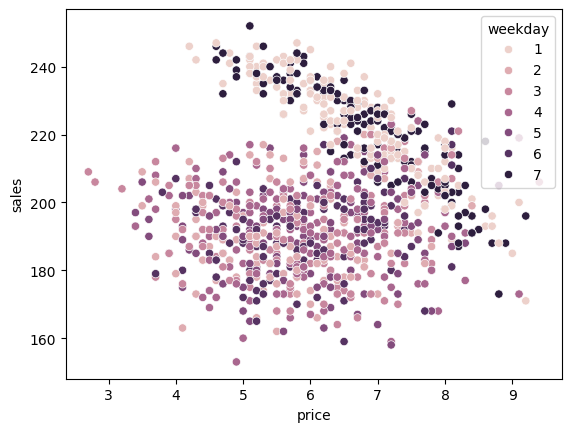

In [19]:
np.random.seed(123)
sns.scatterplot(data=test.sample(1000), x="price", y="sales", hue="weekday");

## Orthogonalising Price and Sales

Let's use orthogonalised price and sales to see if we can further throw some light on a positive relationship between sales and price

The first model, let's call it $M_t(X)$, predicts the treatment (price, in our case) using the confounders.


In [20]:
m_t = smf.ols("price ~ cost + C(weekday) + temp", data=test).fit()

debiased_test = test.assign(**{"price-Mt(X)":test["price"] - m_t.predict(test)})

We can construct the residuals

$$
\hat{t}_i = t_i - M_t(X_i)
$$

You can think of this residual  that is impossible to predict from the confounders $X$.

Since the confounders were already used to predict $t$, the residual is by definition, unpredictable with $X$.

This only works if we have in $X$ all the confounders that cause both $T$ and $Y$.

We can also plot this data to see what it looks like.

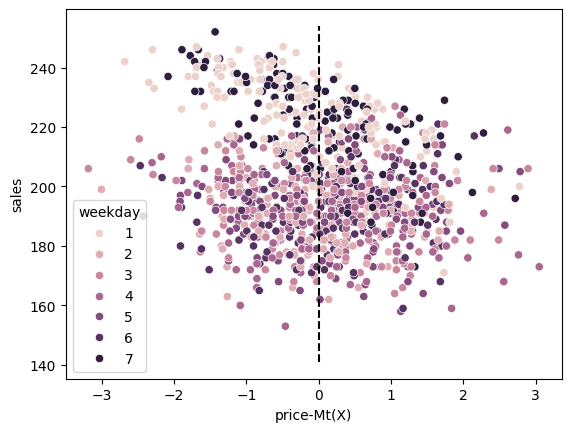

In [21]:
np.random.seed(123)
sns.scatterplot(data=debiased_test.sample(1000), x="price-Mt(X)", y="sales", hue="weekday")
plt.vlines(0, debiased_test["sales"].min(), debiased_test["sales"].max(), linestyles='--', color="black");

We can see that the weekends are no longer to the upper right corner. Moreover, there is less differentiation between different price levels (the treatment) using the weekdays.

Let's construct residuals for the outcome.

$$
\hat{y}_i = y_i - M_y(X_i)
$$
  

$\hat{y}_i$ as a version of $y_i$ that is unpredictable from $X$ or that had all its variances due to $X$ explained away.

We've already used $X$ to predict $y$ with $M_y(X_i)$. And $\hat{y}_i$ is the error of this prediction.

So, by definition, it's not possible to predict it from $X$.

All the information in $X$ to predict $y$ has already been used. If that is the case, the only thing left to explain $\hat{y}_i$ is something we didn't used to construct it (not included in $X$), which is only the treatment (again, assuming no unmeasured confounders).

Q.ii $\hat{y}_i$ is a version of $y_i$ that is unpredictable from $X$ or that had all its variances due to $X$ explained away.

Is this another way of saying that $\hat{y}_i$ and $X$  are orthogonal?



In [22]:
# Orthogonalize price and sales
m_y = smf.ols("sales ~ cost + C(weekday) + temp", data=test).fit()
sales_orthogonalized = test["sales"] - m_y.predict(test)

# Assign the residuals to a new column in debiased_test
debiased_test["sales-My(X)"] = test["sales"] - m_y.predict(test) # This line was missing

m_t = smf.ols("price ~ cost + C(weekday) + temp", data=test).fit()
price_orthogonalized = test["price"] - m_t.predict(test)

debiased_test["price-Mt(X)"] = test["price"] - m_t.predict(test)

# Create a DataFrame with orthogonalized variables
orthogonalized_data = pd.DataFrame({
    "sales_orthogonalized": sales_orthogonalized,
    "price_orthogonalized": price_orthogonalized
})


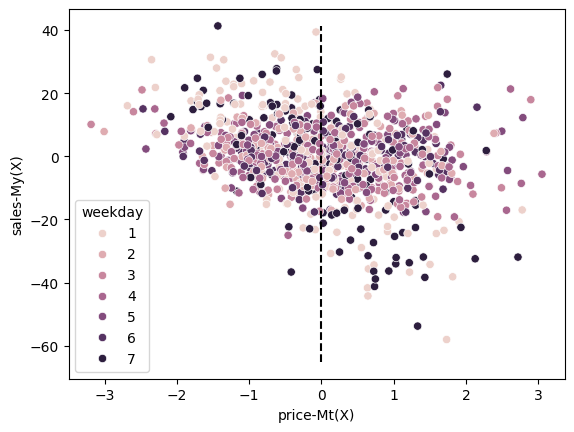

In [23]:

# Plotting
np.random.seed(123)
sns.scatterplot(data=debiased_test.sample(1000), x="price-Mt(X)", y="sales-My(X)", hue="weekday")
plt.vlines(0, debiased_test["sales-My(X)"].min(), debiased_test["sales-My(X)"].max(), linestyles='--', color="black");

In [24]:
# Bivariate regression
m_orthogonalized = smf.ols("sales_orthogonalized ~ price_orthogonalized", data=orthogonalized_data).fit()

# Print results
print(m_orthogonalized.params)

Intercept              -1.227074e-13
price_orthogonalized   -4.062138e+00
dtype: float64


## OLS (original variables)

In [25]:
m_yols = smf.ols("sales ~ price + cost + C(weekday) + temp", data=test).fit()
print(m_yols.params)

Intercept          203.659956
C(weekday)[T.2]    -33.724552
C(weekday)[T.3]    -33.605807
C(weekday)[T.4]    -33.571727
C(weekday)[T.5]    -33.778394
C(weekday)[T.6]    -33.774261
C(weekday)[T.7]     -0.098443
price               -4.062138
cost                 2.876249
temp                 1.791185
dtype: float64


## Plotting the Orthogonalised Variables

 In the plot above, it was hard to know the direction of the price elasticity.

When we plot the orthogonalised variables  we observe a negative relationship between price and sales, suggesting that as price increases, sales tend to decrease.

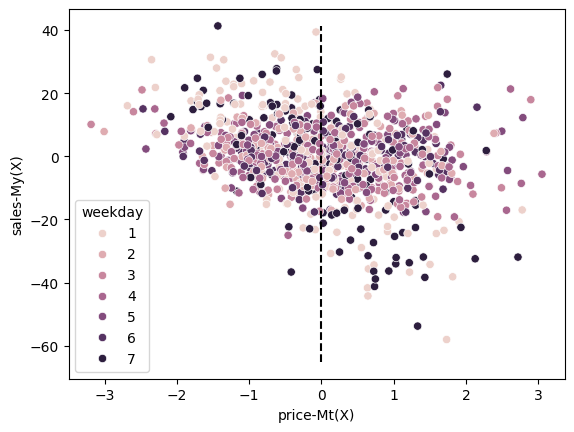

In [26]:
np.random.seed(123)
sns.scatterplot(data=debiased_test.sample(1000), x="price-Mt(X)", y="sales-My(X)", hue="weekday")
plt.vlines(0, debiased_test["sales-My(X)"].min(), debiased_test["sales-My(X)"].max(), linestyles='--', color="black");

## Q. iii Based on the plot above explain the outcomes  when controlling for Weekday Effects


## Orthogonalization with Machine Learning (Topic 5 and 6)

In a 2016 paper, Victor Chernozhukov *et all* showed that you can also do orthogonalization with machine learning models. This is obviously very recent science and we still have much to discover on what we can and can't do with ML models. Still, it's a very interesting idea to know about.

We now use machine learning models for the debiasing.

$$
\begin{align}
\hat{y}_i &= y_i - M_y(X_i) \\
\hat{t}_i &= t_i - M_t(X_i)
\end{align}
$$

There is a catch, though. As we know very well, machine learning models are so powerful that they can fit the data perfectly, or rather, overfit. Just by looking at the equations above, we can know what will happen in that case. If $M_y$ somehow overfits, the residuals will all be very close to zero. If that happens, it will be hard to find how $t$ affects it. Similarly, if $M_t$ somehow overfits, its residuals will also be close to zero. Hence, there won't be variation in the treatment residual to see how it can impact the outcome.

To account for that, we need to do sample splitting. That is, we estimate the model with one part of the dataset and we make predictions in the other part. The simplest way to do this is to split the test sample in half, make two models  in such a way that each one is estimated in one half of the dataset and makes predictions in the other half.

A slightly more elegant implementation uses K-fold cross validation. The advantage being that we can train all the models on a sample which is bigger than half the test set.

![img](./data/img/orthogonal/kfold-cv.png)

<!-- Fortunately, this sort of cross prediction is very easy to implement using Sklearn's `cross_val_predict` function. -->



## Key Ideas

We've started the chapter by highlighting the necessity of random treatment assignment in order for our causal evaluation methods to work. This poses a problem in the case where random data is not available. To be clear, the safest solution in this case is to go and do some experiments in order to get random data. If that is out of the question, only then, we can rely on a clever alternative: transform our data to look as if the treatment has been randomly assigned.

Here, we've covered how to do that using the principles of orthogonalization. First, we've built a model that uses our features $X$ to predict the treatment $t$ and get it's residuals. The idea being that the treatment residuals is, by definition, independent of the features used to construct it. In other words, the treatment residuals are orthogonal to the features. We can see these residuals as a version of the treatment where all the confounding bias due to $X$ has been removed.

That alone is enough to make our data look as good as random. But we can go one step further. We can build a model that predicts the outcome $y$ using the features $X$ but not the treatment and also get its residuals. Again, the intuition is very similar. These outcome residuals is a version of the outcome where all the variance due to the features has been explained away. That will hopefully explay a lot of the variance, making it easier to see the treatment effect.

Here we are using orthogonalization with the goal of debiasing our data for model evaluation. However, this technique is also used for other purposes. Namely, lot's of causal inference models use orthogonalization as a first pre-processing step to ease the task of the causal inference model. We can say that orthogonalization makes the foundation of many modern causal inference algorithms.

![img](./data/img/orthogonal/athlas.png)


